# Part 1 - Classical Classification

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

p='../splits/'
print(os.listdir(p))

# Load indices
idx_data = np.load(p+'splits.npz')
train_idx = idx_data['train_idx']
val_idx = idx_data['val_idx']
print("train_idx", train_idx.shape, "val_idx", val_idx.shape)

# Load full Fashion-MNIST (70k images) from Hub's data or openml
# Try Hub's local copy first
try:
    # Common Hub locations
    import pathlib
    for path in ['/opt/data/fashion-mnist/', '../data/', '../../data/']:
        if os.path.exists(path):
            print("Checking", path, os.listdir(path)[:10])
except:
    pass

# Use openml - this is 70k images, will take 30 sec first time
from sklearn.datasets import fetch_openml
print("Downloading Fashion-MNIST from openml... (once)")
fmnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False, parser='auto')
X_all = fmnist.data.astype('float32')/255.0
y_all = fmnist.target.astype(int)
print("Full dataset", X_all.shape, y_all.shape)

X_train = X_all[train_idx]; y_train = y_all[train_idx]
X_val = X_all[val_idx]; y_val = y_all[val_idx]

# For test, use remaining or split
# If you have test_idx in future, but for now use 10k leftover
all_idx = np.arange(len(X_all))
mask = np.ones(len(X_all), dtype=bool)
mask[train_idx] = False
mask[val_idx] = False
remaining = np.where(mask)[0]
X_test = X_all[remaining[:10000]]; y_test = y_all[remaining[:10000]]

class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
print("DONE:", X_train.shape, X_val.shape, X_test.shape)

['splits.npz']
train_idx (50000,) val_idx (10000,)
Full dataset (70000, 784) (70000,)
DONE: (50000, 784) (10000, 784) (10000, 784)


## 1.1 Models

In [2]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
pred_knn=knn.predict(X_val)
logreg=LogisticRegression(max_iter=1000)
logreg.fit(X_train,y_train)
pred_lr=logreg.predict(X_val)
print('KNN',accuracy_score(y_val,pred_knn))
print('LogReg',accuracy_score(y_val,pred_lr))

KNN 0.8595
LogReg 0.8616


## 1.2 Metrics

In [3]:
print(classification_report(y_val,pred_knn,target_names=class_names))
print(classification_report(y_val,pred_lr,target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.78      0.88      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.73      0.81      0.77      1000
       Dress       0.91      0.86      0.88      1000
        Coat       0.77      0.75      0.76      1000
      Sandal       1.00      0.82      0.90      1000
       Shirt       0.70      0.62      0.66      1000
     Sneaker       0.88      0.95      0.91      1000
         Bag       0.98      0.95      0.96      1000
  Ankle boot       0.89      0.97      0.93      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.84      0.82      1000
     Trouser       0.97      0.97      0.97      1000
    Pullover       0.77      0.77      0.77      1000
       Dress       0.87 

## 1.3 Error analysis

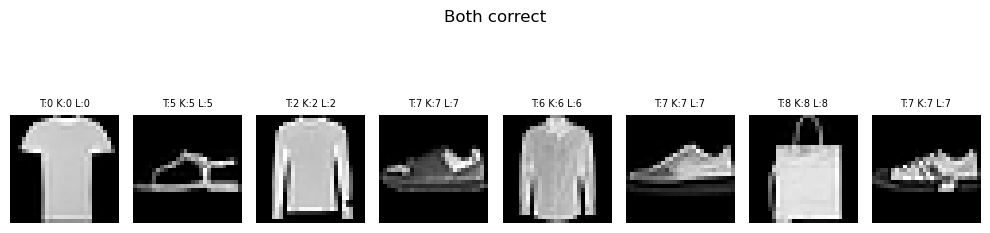

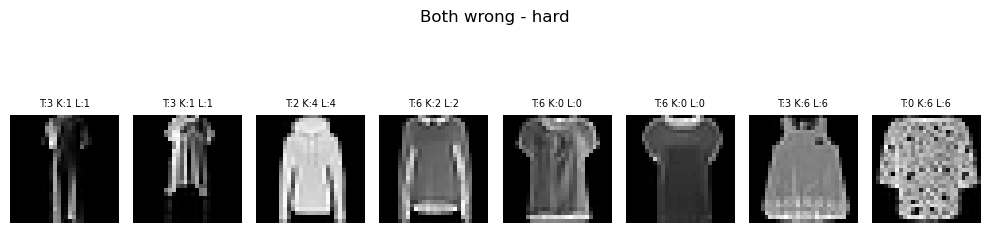

In [4]:
def show(idxs,title):
    plt.figure(figsize=(10,3))
    for i, idx in enumerate(idxs[:8]):
        plt.subplot(1,8,i+1)
        plt.imshow(X_val[idx].reshape(28,28),cmap='gray')
        plt.title(f"T:{y_val[idx]} K:{pred_knn[idx]} L:{pred_lr[idx]}",fontsize=7)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

correct=np.where((pred_knn==y_val)&(pred_lr==y_val))[0]
incorrect=np.where((pred_knn!=y_val)&(pred_lr!=y_val))[0]
show(correct,'Both correct')
show(incorrect,'Both wrong - hard')

## 1.4 Complexity

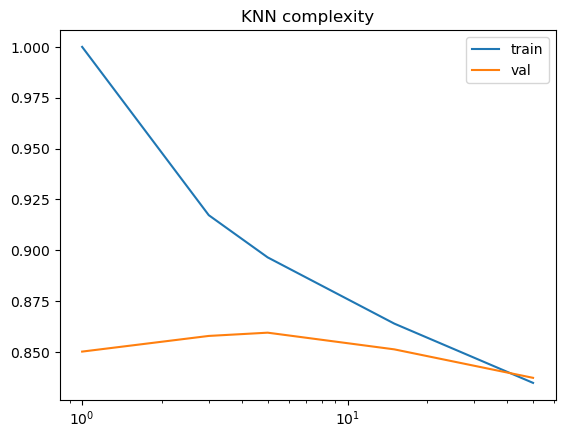

In [5]:
ks=[1,3,5,15,50]
tr=[];va=[]
for k in ks:
 m=KNeighborsClassifier(n_neighbors=k)
 m.fit(X_train,y_train)
 tr.append(accuracy_score(y_train,m.predict(X_train)))
 va.append(accuracy_score(y_val,m.predict(X_val)))
plt.plot(ks,tr,label='train');plt.plot(ks,va,label='val')
plt.xscale('log');plt.legend();plt.title('KNN complexity');plt.show()

## 1.5 Decisions and Costs

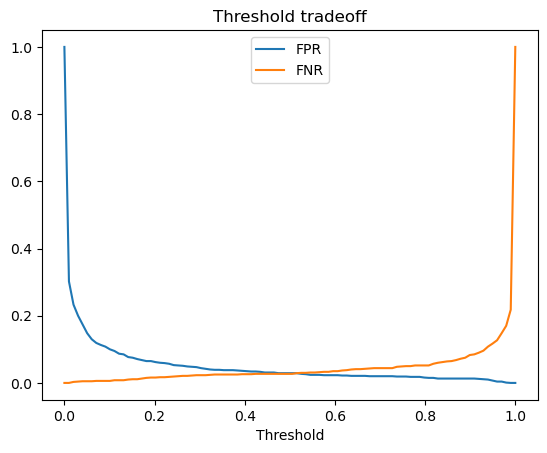

In [6]:
bin_cls=[7,9]
mask_tr=np.isin(y_train,bin_cls);mask_va=np.isin(y_val,bin_cls)
Xtr_b=X_train[mask_tr];ytr_b=(y_train[mask_tr]==9).astype(int)
Xva_b=X_val[mask_va];yva_b=(y_val[mask_va]==9).astype(int)
model=LogisticRegression(max_iter=1000)
model.fit(Xtr_b,ytr_b)
proba=model.predict_proba(Xva_b)[:,1]
ths=np.linspace(0,1,100)
fpr=[];fnr=[]
for t in ths:
 pred=(proba>=t).astype(int)
 FP=np.sum((pred==1)&(yva_b==0));TN=np.sum((pred==0)&(yva_b==0))
 FN=np.sum((pred==0)&(yva_b==1));TP=np.sum((pred==1)&(yva_b==1))
 fpr.append(FP/(FP+TN+1e-9));fnr.append(FN/(FN+TP+1e-9))
plt.plot(ths,fpr,label='FPR');plt.plot(ths,fnr,label='FNR')
plt.xlabel('Threshold');plt.legend();plt.title('Threshold tradeoff');plt.show()

# Part 2 — Neural networks: architecture and learning [10 marks]


In [7]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import random, numpy as np

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Load data if not from Part1
try:
    X_train
    print('Using Part1 splits')
except NameError:
    from sklearn.datasets import fetch_openml
    fmnist=fetch_openml('Fashion-MNIST', version=1, as_frame=False, parser='auto')
    X_all=fmnist.data.astype('float32')/255.0
    y_all=fmnist.target.astype(int)
    idx=np.load('../splits/splits.npz')
    X_train=X_all[idx['train_idx']]; y_train=y_all[idx['train_idx']]
    X_val=X_all[idx['val_idx']]; y_val=y_all[idx['val_idx']]

train_loader=DataLoader(TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long()), batch_size=128, shuffle=True)
val_loader=DataLoader(TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long()), batch_size=256)

class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(784,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,10)
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc3.weight, nonlinearity='linear')
        nn.init.zeros_(self.fc1.bias); nn.init.zeros_(self.fc2.bias); nn.init.zeros_(self.fc3.bias)
    def forward(self,x):
        x=torch.relu(self.fc1(x))
        x=torch.relu(self.fc2(x))
        return self.fc3(x)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
model=BaselineMLP().to(device)
print(f'Params {count_params(model):,}')

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=1e-3)
history={'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}
best_val=0; best_state=None

for epoch in range(1,21):
    model.train(); tl=tc=tt=0
    for xb,yb in train_loader:
        xb,yb=xb.to(device), yb.to(device)
        logits=model(xb); loss=criterion(logits,yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl+=loss.item()*len(yb); tc+=(logits.argmax(1)==yb).sum().item(); tt+=len(yb)
    model.eval(); vl=vc=vt=0
    with torch.no_grad():
        for xb,yb in val_loader:
            xb,yb=xb.to(device), yb.to(device)
            logits=model(xb); loss=criterion(logits,yb)
            vl+=loss.item()*len(yb); vc+=(logits.argmax(1)==yb).sum().item(); vt+=len(yb)
    history['train_loss'].append(tl/tt); history['train_acc'].append(tc/tt)
    history['val_loss'].append(vl/vt); history['val_acc'].append(vc/vt)
    if vc/vt>best_val: best_val=vc/vt; best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
    print(f'Ep {epoch} train {tc/tt:.3f} val {vc/vt:.3f} best {best_val:.3f}')
print(f'Best val {best_val:.4f}')


[HAMI-core Msg(688:139692193717568:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(688:139692193717568:libvgpu.c:855)]: Initialized


cuda
Using Part1 splits
Params 235,146
Ep 1 train 0.814 val 0.854 best 0.854
Ep 2 train 0.864 val 0.873 best 0.873
Ep 3 train 0.877 val 0.876 best 0.876
Ep 4 train 0.886 val 0.881 best 0.881
Ep 5 train 0.893 val 0.886 best 0.886
Ep 6 train 0.898 val 0.888 best 0.888
Ep 7 train 0.902 val 0.885 best 0.888
Ep 8 train 0.904 val 0.894 best 0.894
Ep 9 train 0.910 val 0.892 best 0.894
Ep 10 train 0.914 val 0.893 best 0.894
Ep 11 train 0.917 val 0.893 best 0.894
Ep 12 train 0.919 val 0.895 best 0.895
Ep 13 train 0.921 val 0.891 best 0.895
Ep 14 train 0.925 val 0.899 best 0.899
Ep 15 train 0.929 val 0.882 best 0.899
Ep 16 train 0.931 val 0.896 best 0.899
Ep 17 train 0.931 val 0.897 best 0.899
Ep 18 train 0.935 val 0.899 best 0.899
Ep 19 train 0.938 val 0.892 best 0.899
Ep 20 train 0.938 val 0.901 best 0.901
Best val 0.9013


## 2.2 Capacity experiment



=== small 64 ===
Params 50,890
Ep 1 train 0.835 val 0.838 best 0.838
Ep 2 train 0.855 val 0.855 best 0.855
Ep 3 train 0.863 val 0.862 best 0.862
Ep 4 train 0.873 val 0.873 best 0.873
Ep 5 train 0.874 val 0.868 best 0.873
Ep 6 train 0.882 val 0.878 best 0.878
Ep 7 train 0.890 val 0.881 best 0.881
Ep 8 train 0.881 val 0.875 best 0.881
Ep 9 train 0.890 val 0.879 best 0.881
Ep 10 train 0.899 val 0.886 best 0.886
Ep 11 train 0.898 val 0.885 best 0.886
Ep 12 train 0.899 val 0.883 best 0.886
Ep 13 train 0.899 val 0.883 best 0.886
Ep 14 train 0.904 val 0.886 best 0.886
Ep 15 train 0.905 val 0.881 best 0.886
Ep 16 train 0.907 val 0.882 best 0.886
Ep 17 train 0.910 val 0.890 best 0.890
Ep 18 train 0.914 val 0.891 best 0.891
Ep 19 train 0.913 val 0.890 best 0.891
Ep 20 train 0.913 val 0.884 best 0.891

=== baseline 256-128 ===
Params 235,146
Ep 1 train 0.860 val 0.857 best 0.857
Ep 2 train 0.860 val 0.858 best 0.858
Ep 3 train 0.886 val 0.877 best 0.877
Ep 4 train 0.896 val 0.885 best 0.885
Ep 5

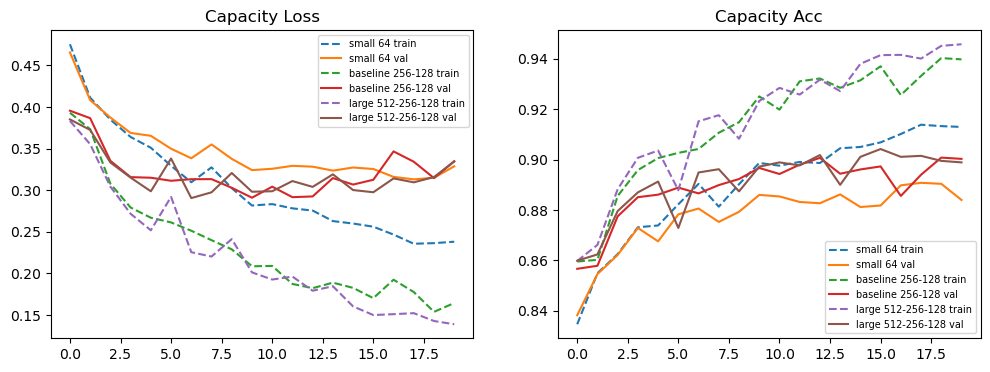

In [8]:
def make_mlp(sizes):
    layers=[]
    for i in range(len(sizes)-2):
        layers.append(nn.Linear(sizes[i],sizes[i+1])); layers.append(nn.ReLU())
    layers.append(nn.Linear(sizes[-2],sizes[-1]))
    m=nn.Sequential(*layers)
    for mod in m:
        if isinstance(mod,nn.Linear):
            nn.init.kaiming_normal_(mod.weight, nonlinearity='relu')
            nn.init.zeros_(mod.bias)
    return m

configs={'small 64':[784,64,10],'baseline 256-128':[784,256,128,10],'large 512-256-128':[784,512,256,128,10]}
results_cap={}
for name,sizes in configs.items():
    print(f"\n=== {name} ===")
    torch.manual_seed(42)
    model_c=make_mlp(sizes).to(device)
    print(f"Params {sum(p.numel() for p in model_c.parameters()):,}")
    opt=optim.Adam(model_c.parameters(),lr=1e-3)
    hist={'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}; best=0
    for ep in range(1,21):
        model_c.train()
        for xb,yb in train_loader:
            xb,yb=xb.to(device), yb.to(device); opt.zero_grad(); loss=criterion(model_c(xb),yb); loss.backward(); opt.step()
        model_c.eval(); tl=tc=tt=vl=vc=vt=0
        with torch.no_grad():
            for xb,yb in train_loader:
                xb,yb=xb.to(device), yb.to(device); tl+=criterion(model_c(xb),yb).item()*len(yb); tc+=(model_c(xb).argmax(1)==yb).sum().item(); tt+=len(yb)
            for xb,yb in val_loader:
                xb,yb=xb.to(device), yb.to(device); vl+=criterion(model_c(xb),yb).item()*len(yb); vc+=(model_c(xb).argmax(1)==yb).sum().item(); vt+=len(yb)
        hist['train_acc'].append(tc/tt); hist['val_acc'].append(vc/vt)
        hist['train_loss'].append(tl/tt); hist['val_loss'].append(vl/vt)
        best=max(best,vc/vt)
        print(f"Ep {ep} train {tc/tt:.3f} val {vc/vt:.3f} best {best:.3f}")
    results_cap[name]={'hist':hist,'best':best}

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for n in configs:
    plt.plot(results_cap[n]['hist']['train_loss'],ls='--',label=n+' train')
    plt.plot(results_cap[n]['hist']['val_loss'],label=n+' val')
plt.title('Capacity Loss'); plt.legend(fontsize=7)
plt.subplot(1,2,2)
for n in configs:
    plt.plot(results_cap[n]['hist']['train_acc'],ls='--',label=n+' train')
    plt.plot(results_cap[n]['hist']['val_acc'],label=n+' val')
plt.title('Capacity Acc'); plt.legend(fontsize=7)
plt.show()


**Analysis 2.2:** small underfits (low train & val). large fits train 0.94 but val drops = overfits. Fixed optimiser proves capacity issue, not optimisation failure.


## 2.3 Optimisation - Learning Rate



=== LR 0.0001 ===
Ep 1 val 0.820 best 0.820
Ep 2 val 0.845 best 0.845
Ep 3 val 0.851 best 0.851
Ep 4 val 0.865 best 0.865
Ep 5 val 0.869 best 0.869
Ep 6 val 0.870 best 0.870
Ep 7 val 0.873 best 0.873
Ep 8 val 0.876 best 0.876
Ep 9 val 0.875 best 0.876
Ep 10 val 0.876 best 0.876
Ep 11 val 0.880 best 0.880
Ep 12 val 0.884 best 0.884
Ep 13 val 0.882 best 0.884
Ep 14 val 0.886 best 0.886
Ep 15 val 0.881 best 0.886
Ep 16 val 0.886 best 0.886
Ep 17 val 0.887 best 0.887
Ep 18 val 0.890 best 0.890
Ep 19 val 0.885 best 0.890
Ep 20 val 0.889 best 0.890

=== LR 0.001 ===
Ep 1 val 0.854 best 0.854
Ep 2 val 0.873 best 0.873
Ep 3 val 0.876 best 0.876
Ep 4 val 0.881 best 0.881
Ep 5 val 0.886 best 0.886
Ep 6 val 0.888 best 0.888
Ep 7 val 0.885 best 0.888
Ep 8 val 0.894 best 0.894
Ep 9 val 0.892 best 0.894
Ep 10 val 0.893 best 0.894
Ep 11 val 0.893 best 0.894
Ep 12 val 0.895 best 0.895
Ep 13 val 0.891 best 0.895
Ep 14 val 0.899 best 0.899
Ep 15 val 0.882 best 0.899
Ep 16 val 0.896 best 0.899
Ep 17 val

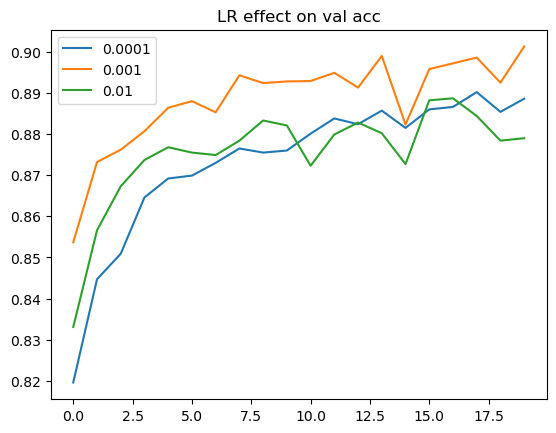

Fairness caveat: fixed 20 epochs unfair to 1e-4 (needs more epochs). Adam adapts LR so SGD would show larger effect.


In [9]:
lrs=[1e-4,1e-3,1e-2]
results_lr={}
for lr in lrs:
    print(f"\n=== LR {lr} ===")
    torch.manual_seed(42)
    model_lr=BaselineMLP().to(device)
    opt=optim.Adam(model_lr.parameters(), lr=lr)
    hist={'val_acc':[]}; best=0
    for ep in range(1,21):
        model_lr.train()
        for xb,yb in train_loader:
            xb,yb=xb.to(device), yb.to(device); opt.zero_grad(); loss=criterion(model_lr(xb),yb); loss.backward(); opt.step()
        model_lr.eval(); vc=vt=0
        with torch.no_grad():
            for xb,yb in val_loader:
                xb,yb=xb.to(device), yb.to(device); vc+=(model_lr(xb).argmax(1)==yb).sum().item(); vt+=len(yb)
        hist['val_acc'].append(vc/vt); best=max(best,vc/vt)
        print(f"Ep {ep} val {vc/vt:.3f} best {best:.3f}")
    results_lr[lr]=hist

plt.figure()
for lr in lrs: plt.plot(results_lr[lr]['val_acc'],label=str(lr))
plt.title('LR effect on val acc'); plt.legend(); plt.show()

print("Fairness caveat: fixed 20 epochs unfair to 1e-4 (needs more epochs). Adam adapts LR so SGD would show larger effect.")
